<a href="https://colab.research.google.com/github/Sakshi-zz/Machine_Failure_prediction_model/blob/main/Sakshi_Rana_Machine_Failure_Prediction_Model_Data_Science_July_Batch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **# Machine Failure Prediction Project**

---



## **Dataset Overview**
This dataset contains sensor data collected from various machines , with the aim of predicting machine failures in advance. It include a variety of sensor reading as well as the recorded machine failures.


## **Columns Description**

*   Footfall: The number of people or objects passing by the machine.
*   TempMode: The temperature mode or setting of the machine.
*   AQ: Air quality index near the machine.
*   USS: Ulterasonic sensor data, indicating proximity measurements.
*   CS: Current sensor reading, indicating the electrical current usage of
    machine
*   VOC: Volatile organic compounds level detected near the machine.
*   RP: Rotational position or RPM (revolutions per minute) of the machine.
*   IP: Imput pressure to the machine.
*   Temperature: The operating temperature of the machine.
*   Fail: Binary indicator of machine failure (1 for failure, 0 for no failure).


---



## Import the necessary liberaries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## Load dataset

In [ ]:
sensor_data = pd.read_csv('/content/data (1).csv')
sensor_data

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0
...,...,...,...,...,...,...,...,...,...,...
939,0,7,7,1,6,4,73,6,24,1
940,0,7,5,2,6,6,50,6,24,1
941,0,3,6,2,7,5,43,6,24,1
942,0,6,6,2,5,6,46,7,24,1


## Exploratory Data Analysis (EDA)

In [ ]:
print(sensor_data.isnull().sum())

footfall       0
tempMode       0
AQ             0
USS            0
CS             0
VOC            0
RP             0
IP             0
Temperature    0
fail           0
dtype: int64


In [ ]:
sensor_data.shape

(944, 10)

In [ ]:
sensor_data.columns

Index(['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP',
       'Temperature', 'fail'],
      dtype='object')

In [ ]:
sensor_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   footfall     944 non-null    int64
 1   tempMode     944 non-null    int64
 2   AQ           944 non-null    int64
 3   USS          944 non-null    int64
 4   CS           944 non-null    int64
 5   VOC          944 non-null    int64
 6   RP           944 non-null    int64
 7   IP           944 non-null    int64
 8   Temperature  944 non-null    int64
 9   fail         944 non-null    int64
dtypes: int64(10)
memory usage: 73.9 KB


In [ ]:
sensor_data.describe(include = 'all')

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000
mean,306.381356,3.727754,4.325212,2.939619,5.394068,2.842161,47.043432,4.565678,16.331568,0.416314
std,1082.606745,2.677235,1.438436,1.383725,1.269349,2.273337,16.423130,1.599287,5.974781,0.493208
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,19.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,3.000000,2.000000,5.000000,1.000000,34.000000,3.000000,14.000000,0.000000
50%,22.000000,3.000000,4.000000,3.000000,6.000000,2.000000,44.000000,4.000000,17.000000,0.000000
75%,110.000000,7.000000,6.000000,4.000000,6.000000,5.000000,58.000000,6.000000,21.000000,1.000000
max,7300.000000,7.000000,7.000000,7.000000,7.000000,6.000000,91.000000,7.000000,24.000000,1.000000


In [ ]:
sensor_data.head()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


In [ ]:
sensor_data.tail()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
939,0,7,7,1,6,4,73,6,24,1
940,0,7,5,2,6,6,50,6,24,1
941,0,3,6,2,7,5,43,6,24,1
942,0,6,6,2,5,6,46,7,24,1
943,18,7,4,2,6,3,61,7,24,1


## Data Visualization

In [ ]:
correlation = sensor_data.corr()
print(correlation["fail"])

footfall      -0.073066
tempMode      -0.014462
AQ             0.583238
USS           -0.466574
CS             0.018855
VOC            0.797329
RP             0.053668
IP             0.085624
Temperature    0.190257
fail           1.000000
Name: fail, dtype: float64


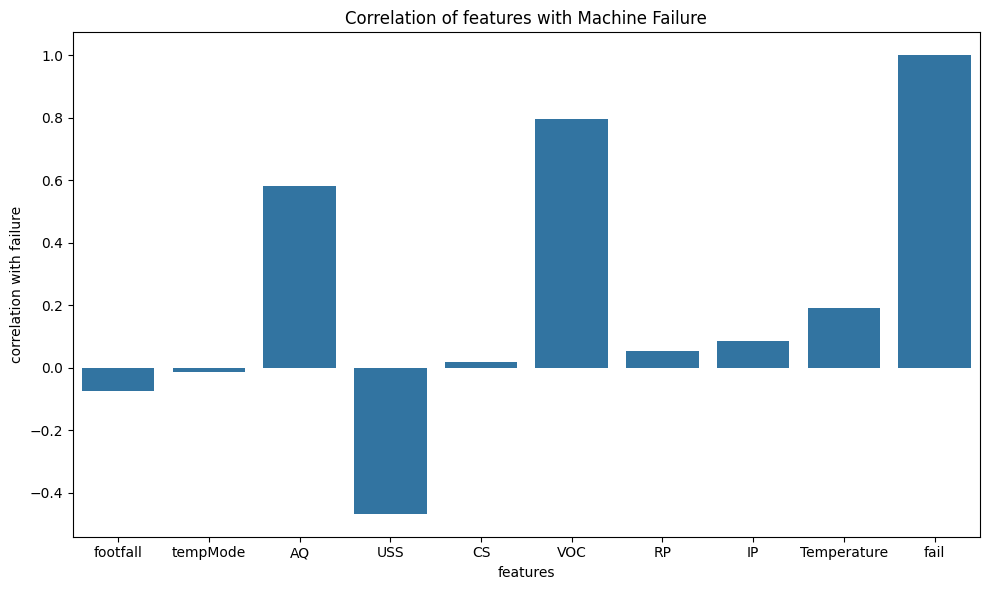

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=correlation['fail'].index , y=correlation['fail'].values)
plt.xlabel("features")
plt.ylabel("correlation with failure")
plt.title("Correlation of features with Machine Failure")
plt.tight_layout()
plt.show()

## Train Test Data Splitting

In [ ]:
feather_col =['footfall','tempMode','AQ','USS','CS','VOC','RP','IP','Temperature']
x = sensor_data[feather_col]
y = sensor_data['fail']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.2,
                                                    random_state = 5)

In [ ]:
display(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(755, 9)

(189, 9)

(755,)

(189,)

## Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver ='lbfgs', max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [ ]:
print(y_pred)
print(y_test)

[0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 0 1 0 1 0 0 1 0 1 0 0 0 1 1 1 0 0 0 1
 1 0 0 0 1 1 0 1 0 1 1 1 0 1 1 0 0 0 0 1 1 1 1 0 0 1 1 1 0 0 0 0 1 0 0 1 0
 1 1 1 1 0 0 0 1 1 1 0 1 1 1 1 0 1 0 0 0 0 1 1 1 0 0 1 0 0 1 0 1 1 1 1 0 0
 0 1 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 1
 0 0 0 0 0 0 1 1 1 0 0 1 1 1 0 1 1 0 1 1 1 1 0 0 1 0 0 0 1 1 1 1 0 0 1 0 0
 0 1 0 0]
60     0
512    1
924    0
629    0
72     1
      ..
427    0
804    0
890    1
464    0
651    0
Name: fail, Length: 189, dtype: int64


In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix =confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[88  8]
 [ 8 85]]


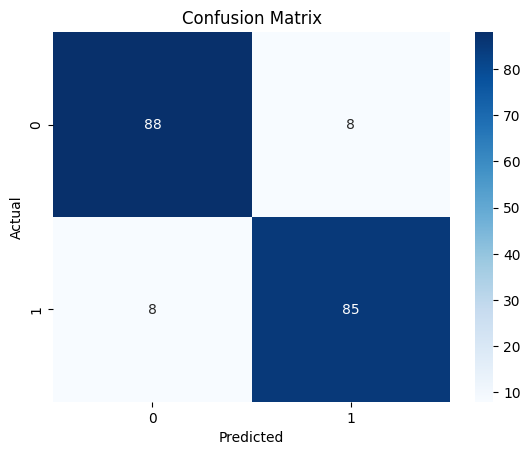

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# feature predict data model

import pandas as pd
new_data = pd.DataFrame({
    'footfall':[100],
    'tempMode':[26],
    'AQ':[50],
    'USS':[10],
    'CS':[1.5],
    'VOC':[200],
    'RP':[1500],
    'IP':[10],
    'Temperature':[30],
})
new_prediction = model.predict(new_data)
print(new_prediction)

[1]


In [ ]:
print("R-sqr value: ", model.score(x,y))

R-sqr value:  0.9120762711864406


In [ ]:
print("mean absolute error rate: ", np.mean(np.absolute(y_pred-y_test)))

mean absolute error rate:  0.08465608465608465


In [ ]:
print("mean squared error rate: ", np.mean((y_pred-y_test)**2))

mean squared error rate:  0.08465608465608465


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
y_pred_rounded = np.round(y_pred)
accuracy = accuracy_score(y_test, y_pred_rounded)
print("Accuracy:",accuracy)
accuracy_percentage = accuracy * 100
print("Accuracy: {:.2f}%".format(accuracy_percentage))

Accuracy: 0.9153439153439153
Accuracy: 91.53%
